In [1]:
import pandas as pd
df = pd.read_csv('https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/protein_expression_data.csv')


df['specimen_id']=df.VisSpot.apply(lambda x: x.split('-')[2]) #create specimen id field
df['image_id']=df.VisSpot.apply(lambda x: x.split('-')[2])+'_'+df.id #create image id field
df = df.set_index('image_id').sort_index()
protein_names = ['SMAa', 'CD11b',
       'CD44', 'CD31', 'CDK4', 'YKL40', 'CD11c', 'HIF1a', 'CD24', 'TMEM119',
       'OLIG2', 'GFAP', 'VISTA', 'IBA1', 'CD206', 'PTEN', 'NESTIN', 'TCIRG1',
       'CD74', 'MET', 'P2RY12', 'CD163', 'S100B', 'cMYC', 'pERK', 'EGFR',
       'SOX2', 'HLADR', 'PDGFRa', 'MCT4', 'DNA1', 'DNA3', 'MHCI', 'CD68',
       'CD14', 'KI67', 'CD16', 'SOX10']
print(df)


          Unnamed: 0                VisSpot  Location_Center_Y  \
image_id                                                         
A1_0x40          412  AAGTAAGCTTCCAAAC-1-A1         764.003658   
A1_0x42         7325  GTTTGAGCGGTTATGT-1-A1         799.511111   
A1_0x44         8102  TCACTCAGCGCATTAG-1-A1         832.902467   
A1_0x46         7085  GTGCGCTTACAAATGA-1-A1         858.343544   
A1_0x48         3748  CGAAGACTGCCCGGGA-1-A1         892.179831   
...              ...                    ...                ...   
D1_9x63         3609  CCTCCCGACAATCCCT-1-D1         123.760525   
D1_9x65          172  AACACGACTGTACTGA-1-D1          29.281573   
D1_9x67         2686  CACCGCCGACCAGCGA-1-D1         938.403662   
D1_9x69         2813  CAGAGTGATTTAACGT-1-D1         844.093656   
D1_9x71         6877  GTCAGTTGTGCTCGTT-1-D1         740.107483   

          Location_Center_X      SMAa     CD11b      CD44      CD31      CDK4  \
image_id                                                    

skimage version 0.25.2


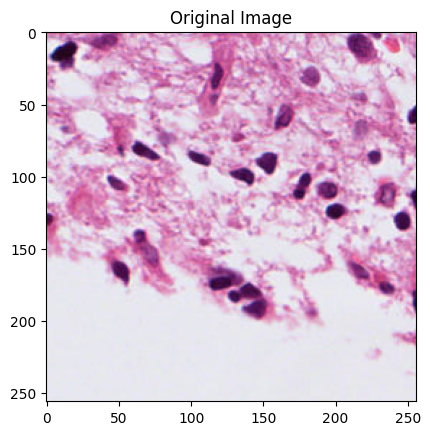

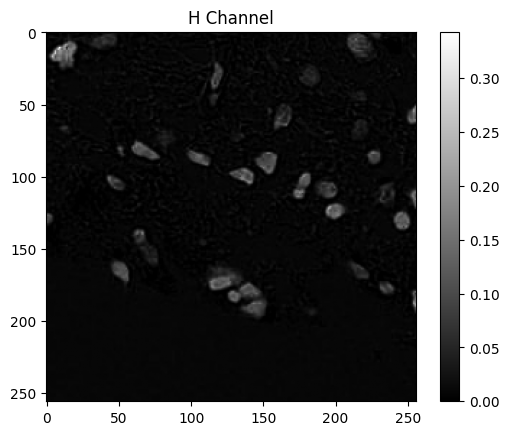

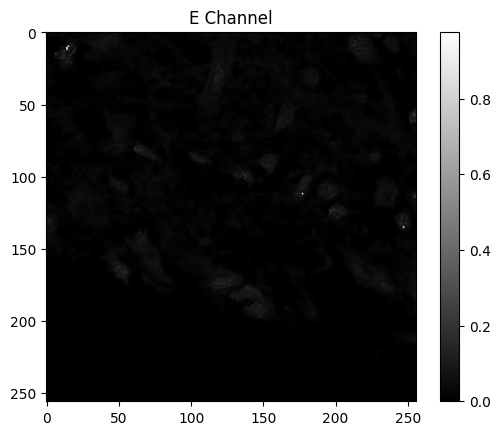

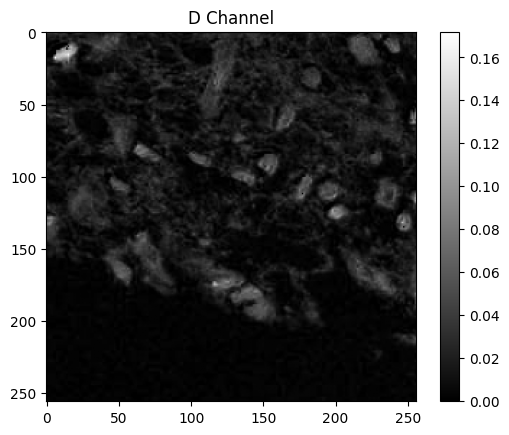

In [2]:
image_folder = 'content/patches_256/'
from skimage.color import rgb2hed
import skimage
from skimage.io import imread
from skimage.color import rgba2rgb
import matplotlib.pyplot as plt

# Replace 'path_to_image' with the path to the image you want to display
image_path = image_folder+'A1_0x40.png'
print('skimage version',skimage.__version__)
import matplotlib.pyplot as plt
I = rgba2rgb(imread(image_path)) #read sample RGB image
I_hed =  rgb2hed(I) #convert to HED
plt.imshow(I);plt.title('Original Image');plt.show()
I_h = I_hed[:,:,0]; plt.figure(); plt.imshow(I_h,cmap='gray');plt.colorbar();plt.title('H Channel');plt.show()
I_e = I_hed[:,:,1]; plt.figure();  plt.imshow(I_e,cmap='gray');plt.colorbar();plt.title('E Channel');plt.show()
I_d = I_hed[:,:,2]; plt.figure();  plt.imshow(I_d,cmap='gray');plt.colorbar();plt.title('D Channel');plt.show()


## Question 1: Shared Structure Between Image Space and Protein Expression Space

### (a) Construct Two Feature Spaces

#### Deliverable (i) Protein Expression Feature Matrix

Each spot is represented as a vector of 38 protein expression values, one per measured protein. Stacking all training spots gives a matrix of shape **N_train × 38**.

The preprocessing step is **z-score standardisation**, where for each protein column we subtract the training-set mean and divide by the training-set standard deviation, so every feature has zero mean and unit variance. This prevents proteins with larger absolute value ranges from dominating downstream PCA and clustering analyses.

In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# split specimens into training set (A1 B1 C1) and test set (D1)
train_df = df[df['specimen_id'].isin(['A1', 'B1', 'C1'])].copy()
test_df  = df[df['specimen_id'] == 'D1'].copy()

print(f"Protein feature matrix dimensions: train = ({len(train_df)}, {len(protein_names)}),  test = ({len(test_df)}, {len(protein_names)})")

Protein feature matrix dimensions: train = (8168, 38),  test = (1753, 38)


#### Deliverable (ii) Image Feature Representation

I represent each image using **summary statistics extracted from both the RGB and HED colour space channels**. For each of the six channels (R, G, B, H, E, D) I compute the mean and standard deviation over all pixels, giving a compact **12-dimensional feature vector** per image.

**Justification.** The RGB channels capture the raw colour distribution of the tissue patch, while the HED colour space separates the three main staining components used in histopathology. The H channel captures nuclear density, the E channel captures cytoplasm and connective tissue (stained pink), and the D channel captures DAB staining intensity directly linked to specific protein markers. Combining both spaces provides complementary information, where RGB reflects overall colour appearance while HED reflects biologically interpretable staining components, making the feature vector more informative for predicting protein expression levels. The extraction is also computationally lightweight, allowing all spots to be processed efficiently.

In [15]:
from skimage.io import imread
from skimage.color import rgba2rgb, rgb2hed
from tqdm import tqdm

# extract mean and std of RGB and HED channels for a single image
def extract_features(image_id):
    path = image_folder + image_id + '.png'
    I = imread(path)
    if I.shape[2] == 4:                              # convert RGBA to RGB only if needed
        I = rgba2rgb(I)                              # rgba2rgb returns float64 in [0, 1]
    else:
        I = I.astype(np.float64) / 255.0             # normalise uint8 RGB to [0, 1]
    I_hed = rgb2hed(I)                               # convert RGB to HED colour space
    feats = []
    for ch in range(3):                              # RGB channels R then G then B
        feats.append(I[:, :, ch].mean())
        feats.append(I[:, :, ch].std())
    for ch in range(3):                              # HED channels H then E then D
        feats.append(I_hed[:, :, ch].mean())
        feats.append(I_hed[:, :, ch].std())
    return np.array(feats)                           # returns a 12-dimensional vector

# load image features for an entire split and track which ids succeeded
def load_image_features(subset_df, desc=''):
    features, valid_ids = [], []
    for img_id in tqdm(subset_df.index, desc=desc):
        try:
            features.append(extract_features(img_id))
            valid_ids.append(img_id)
        except FileNotFoundError:
            pass  # skip spots whose image file is missing from disk
    return np.array(features), valid_ids

X_img_train_raw, train_valid_ids = load_image_features(train_df, desc='Training set')
print(f"{len(train_valid_ids)} / {len(train_df)} training images loaded")

X_img_test_raw, test_valid_ids = load_image_features(test_df, desc='Test set')
print(f"{len(test_valid_ids)} / {len(test_df)} test images loaded")

# align protein features to the same valid image ids so rows correspond
X_prot_train_raw = train_df.loc[train_valid_ids, protein_names].values
X_prot_test_raw  = test_df.loc[test_valid_ids,   protein_names].values

print(f"Protein matrix   train: {X_prot_train_raw.shape}  test: {X_prot_test_raw.shape}")
print(f"Image matrix     train: {X_img_train_raw.shape}  test: {X_img_test_raw.shape}")

Training set: 100%|██████████| 8168/8168 [01:43<00:00, 78.84it/s] 


8168 / 8168 training images loaded


Test set: 100%|██████████| 1753/1753 [00:16<00:00, 104.28it/s]

1753 / 1753 test images loaded
Protein matrix   train: (8168, 38)  test: (1753, 38)
Image matrix     train: (8168, 12)  test: (1753, 12)


#### Deliverable (iii) Standardisation and Prevention of Data Leakage

Both feature spaces are standardised with `StandardScaler`. The critical rule is that **the scaler is fitted on the training set only** (A1, B1, C1), and the test set (D1) is normalised using those same training-set statistics via `.transform()`, not `.fit_transform()`.

This prevents data leakage. Fitting the scaler on the full dataset would let test-set statistics influence the normalisation, giving the model indirect access to D1 information before evaluation. Keeping D1 isolated from the fitting step ensures that performance metrics on D1 reflect genuine generalisation to unseen data.

In [16]:
# fit protein scaler on training data only then apply to both sets
prot_scaler = StandardScaler()
X_prot_train_scaled = prot_scaler.fit_transform(X_prot_train_raw)
X_prot_test_scaled  = prot_scaler.transform(X_prot_test_raw)   # no fit here

# fit image scaler on training data only then apply to both sets
img_scaler = StandardScaler()
X_img_train_scaled = img_scaler.fit_transform(X_img_train_raw)
X_img_test_scaled  = img_scaler.transform(X_img_test_raw)      # no fit here

print("Standardisation complete (scalers fitted on training set only).")
print(f"Protein features  train: {X_prot_train_scaled.shape}  test: {X_prot_test_scaled.shape}")
print(f"Image features    train: {X_img_train_scaled.shape}  test: {X_img_test_scaled.shape}")

Standardisation complete (scalers fitted on training set only).
Protein features  train: (8168, 38)  test: (1753, 38)
Image features    train: (8168, 12)  test: (1753, 12)


### (b) PCA and Intrinsic Dimensionality Analysis

#### Task (i) Scree Plot

We fit PCA separately on the protein and image training sets. The scree plot below shows the proportion of variance explained by each principal component.

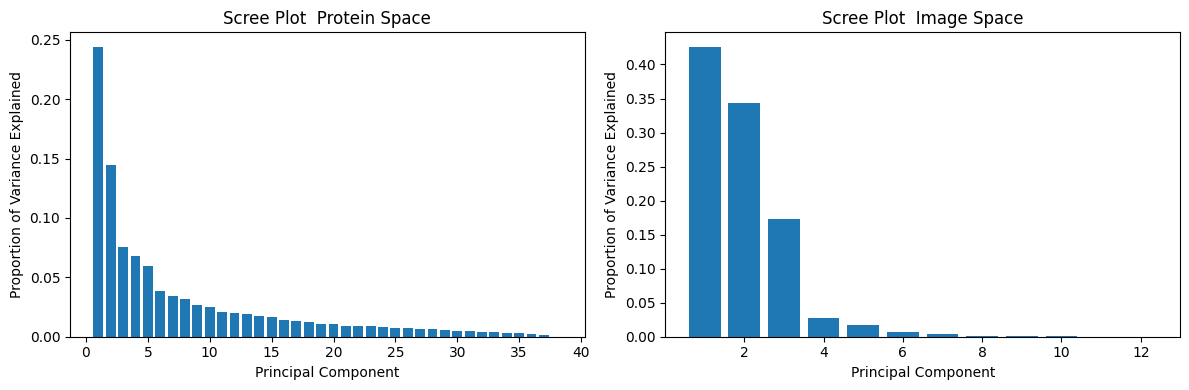

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

output_dir = 'output/'

# fit PCA on training data only for both spaces
pca_prot = PCA()
pca_prot.fit(X_prot_train_scaled)

pca_img = PCA()
pca_img.fit(X_img_train_scaled)

# task (i) scree plot  1x2 layout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_prot.explained_variance_ratio_) + 1),
            pca_prot.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_title('Scree Plot  Protein Space')

axes[1].bar(range(1, len(pca_img.explained_variance_ratio_) + 1),
            pca_img.explained_variance_ratio_)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Proportion of Variance Explained')
axes[1].set_title('Scree Plot  Image Space')

plt.tight_layout()
plt.savefig(output_dir + 'q1b_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

#### Task (ii) Cumulative Variance

The cumulative variance plot shows how many principal components are needed to capture a given proportion of total variance. The dashed line marks the 90% threshold.

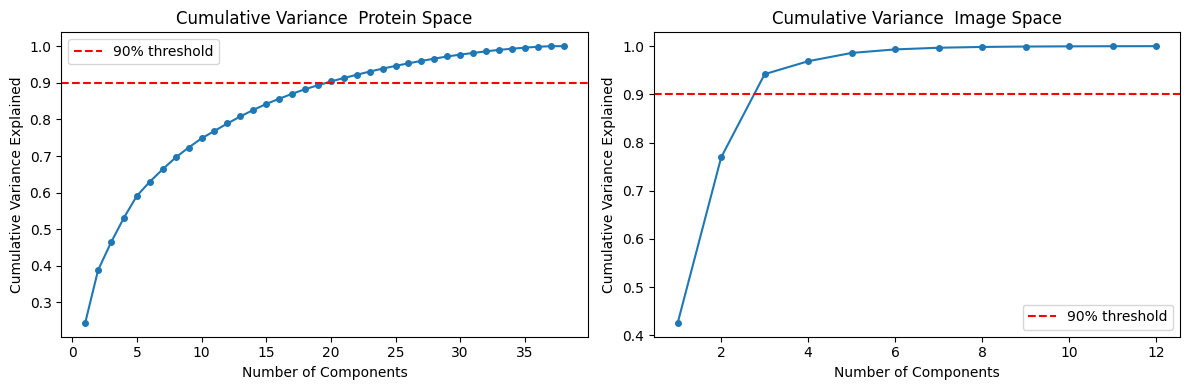

In [18]:
import numpy as np

# task (ii) cumulative variance  1x2 layout
cumvar_prot = np.cumsum(pca_prot.explained_variance_ratio_)
cumvar_img  = np.cumsum(pca_img.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(cumvar_prot) + 1), cumvar_prot, marker='o', markersize=4)
axes[0].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance Explained')
axes[0].set_title('Cumulative Variance  Protein Space')
axes[0].legend()

axes[1].plot(range(1, len(cumvar_img) + 1), cumvar_img, marker='o', markersize=4)
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance  Image Space')
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir + 'q1b_cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Task (iii) Components Required to Retain 90% Variance

In [19]:
# find number of components needed to retain 90% of variance in each space
n_prot_90 = int(np.argmax(cumvar_prot >= 0.90)) + 1
n_img_90  = int(np.argmax(cumvar_img  >= 0.90)) + 1

print(f"Protein space: {n_prot_90} components required to retain 90% of variance")
print(f"Image space  : {n_img_90} components required to retain 90% of variance")

# build reduced representations using the 90% threshold components
X_prot_pca = pca_prot.transform(X_prot_train_scaled)[:, :n_prot_90]
X_img_pca  = pca_img.transform(X_img_train_scaled)[:, :n_img_90]

print(f"Reduced protein PCA matrix shape: {X_prot_pca.shape}")
print(f"Reduced image PCA matrix shape  : {X_img_pca.shape}")

Protein space: 20 components required to retain 90% of variance
Image space  : 3 components required to retain 90% of variance
Reduced protein PCA matrix shape: (8168, 20)
Reduced image PCA matrix shape  : (8168, 3)


#### Task (iv) Interpretation

The image space is far more compressible than the protein space.

For the **protein space**, 20 out of 38 components are needed to retain 90% of the variance. The scree plot shows a gradual, slow decay with no sharp elbow, meaning many proteins contribute distinct variation. The cumulative curve rises steadily, reflecting that biological variation is spread broadly across the 38 protein measurements.

For the **image space**, only 3 out of 12 components are needed to retain 90% of the variance. The scree plot drops sharply after PC3 (PC1 ~42%, PC2 ~35%, PC3 ~17%), and the cumulative curve reaches the 90% threshold almost immediately.

The image space is more compressible because the 12 features (mean and std of R, G, B, H, E, D channels) are derived from the same underlying tissue patch and are highly correlated with each other. For example, the RGB channels and HED channels both reflect the same staining pattern, so much of their variance collapses into a small number of directions. In contrast, the 38 proteins measure distinct biological processes across different cell types, and while some co-expression exists, the protein variation is genuinely higher-dimensional.

This suggests that image appearance can be summarised by a very compact representation (3 dimensions), whereas protein expression profiles carry richer, more independent biological signals that require more dimensions to describe adequately.

### (c) Clustering in PCA Space

#### Task (i) K-means Clustering

We use K=4 because the dataset contains exactly four specimens (A1, B1, C1, D1), which makes the cluster labels directly comparable to specimen identity in Q1(d). All spots (train and test) are projected through the training-fitted PCA before clustering. This does not refit the PCA and introduces no data leakage.

In [20]:
from sklearn.cluster import KMeans
import numpy as np

# project all spots (train and test) through the training-fitted PCA
# transform only, no refit, so D1 statistics do not influence the PCA
X_prot_all_pca = pca_prot.transform(
    np.vstack([X_prot_train_scaled, X_prot_test_scaled]))[:, :n_prot_90]
X_img_all_pca  = pca_img.transform(
    np.vstack([X_img_train_scaled, X_img_test_scaled]))[:, :n_img_90]

# collect specimen labels for all spots in the same row order
specimen_all = np.concatenate([
    train_df.loc[train_valid_ids, 'specimen_id'].values,
    test_df.loc[test_valid_ids,   'specimen_id'].values
])

# fit K-means with K=4 on each PCA space
kmeans_prot = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_prot = kmeans_prot.fit_predict(X_prot_all_pca)

kmeans_img = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_img = kmeans_img.fit_predict(X_img_all_pca)

print(f"Protein space cluster sizes: {np.bincount(labels_prot)}")
print(f"Image space cluster sizes  : {np.bincount(labels_img)}")

Protein space cluster sizes: [5010  391  320 4200]
Image space cluster sizes  : [4263 1813  689 3156]


#### Task (ii) 2D PCA Scatter Plots Coloured by Cluster

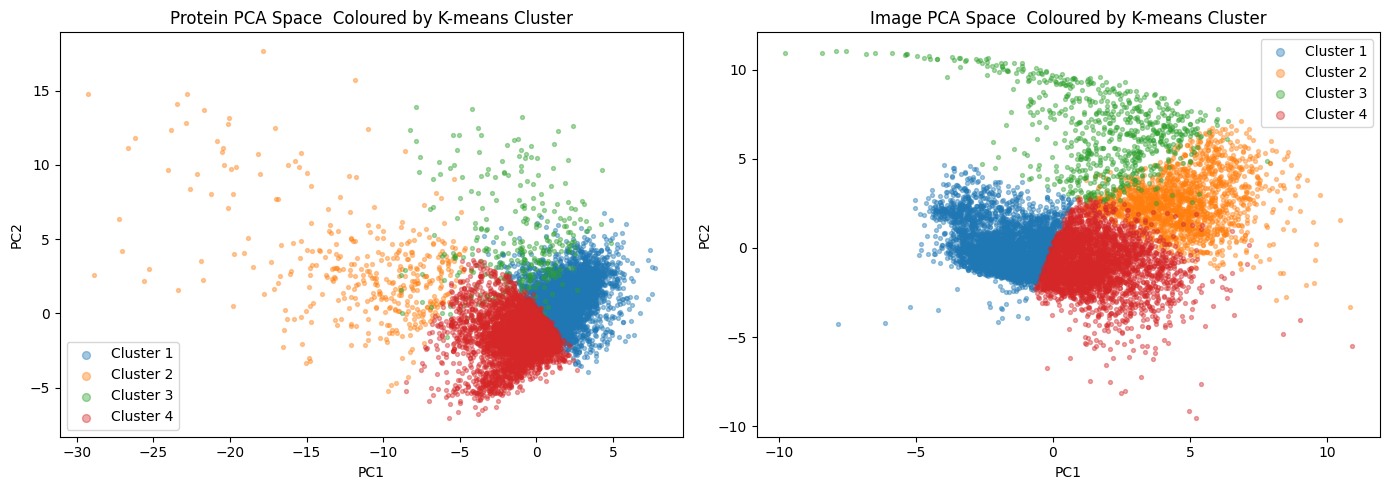

In [21]:
import matplotlib.pyplot as plt

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k in range(4):
    mask = labels_prot == k
    axes[0].scatter(X_prot_all_pca[mask, 0], X_prot_all_pca[mask, 1],
                    c=colors[k], label=f'Cluster {k+1}', alpha=0.4, s=8)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Protein PCA Space  Coloured by K-means Cluster')
axes[0].legend(markerscale=2)

for k in range(4):
    mask = labels_img == k
    axes[1].scatter(X_img_all_pca[mask, 0], X_img_all_pca[mask, 1],
                    c=colors[k], label=f'Cluster {k+1}', alpha=0.4, s=8)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Image PCA Space  Coloured by K-means Cluster')
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig('output/q1c_cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

#### Comment on Cluster Structure

The two spaces show markedly different cluster structures.

In the **protein PCA space**, Clusters 1 and 4 are both large (5010 and 4200 spots respectively) and heavily overlap in the PC1-PC2 projection, while Clusters 2 and 3 are much smaller (391 and 320 spots) and sit further out in the negative PC1 region. The poor visual separation in 2D is consistent with the earlier finding that 20 principal components are needed to retain 90% of the variance, meaning the cluster structure is spread across many dimensions. This pattern suggests the protein clusters are **potentially biological** rather than specimen-driven, as spots group according to multi-dimensional expression patterns that cut across specimen boundaries.

In the **image PCA space**, the four clusters form distinct wedge-shaped sectors radiating from a common origin, producing much less overlap. Since the image features are colour summary statistics, this radial pattern most likely reflects overall colour differences between specimens rather than any finer-grained structure within specimens. The image space clusters therefore appear **specimen-driven**, consistent with between-specimen staining variation dominating the image feature space.

### (d) Association Between Clusters and Specimen Structure

#### Task (i) Image vs Protein Cluster Agreement

In [22]:
from sklearn.metrics import normalized_mutual_info_score

# compute NMI between image-space and protein-space cluster labels
nmi_img_prot = normalized_mutual_info_score(labels_img, labels_prot)
print(f"NMI(image clusters, protein clusters) = {nmi_img_prot:.4f}")

NMI(image clusters, protein clusters) = 0.0917


The NMI value of 0.0917 indicates very weak agreement between the image-space and protein-space clusterings, meaning the two spaces partition the spots in largely independent ways and share little common structure at the cluster level.

#### Task (ii) Cluster vs Specimen Association

In [23]:
import pandas as pd

# compute NMI between each clustering and specimen identity
nmi_img_s  = normalized_mutual_info_score(labels_img,  specimen_all)
nmi_prot_s = normalized_mutual_info_score(labels_prot, specimen_all)

# display all three NMI values as a summary table
nmi_table = pd.DataFrame(
    {'NMI': [nmi_img_prot, nmi_img_s, nmi_prot_s]},
    index=['Image clusters vs Protein clusters',
           'Image clusters vs Specimen NMI(c^img,s)',
           'Protein clusters vs Specimen NMI(c^prot,s)']
)
display(nmi_table.round(4))

,NMI
Image clusters vs Protein clusters,0.0917
"Image clusters vs Specimen NMI(c^img,s)",0.3011
"Protein clusters vs Specimen NMI(c^prot,s)",0.0101


The image clustering is more specimen-driven. Its NMI with specimen identity is 0.3011, which is substantially higher than the corresponding value of 0.0101 for the protein clustering. This confirms that image clusters are meaningfully aligned with which specimen a spot comes from, while protein clusters are almost entirely independent of specimen identity.

#### Task (iii) Interpretation and Reasoning

The NMI values show that the image and protein clusters are more aligned with specimen identity than with each other in the image space, but the reverse is true for the protein space.

For the image clustering, the NMI with specimen (0.3011) is considerably higher than its NMI with protein clusters (0.0917). This suggests that image features primarily reflect between-specimen differences such as staining intensity variation, which is a form of domain shift rather than shared biological structure.

For the protein clustering, the NMI with specimen (0.0101) is near zero, indicating that protein-based groupings are not driven by which specimen a spot originates from. The protein clusters therefore capture variation that is consistent across specimens, which is more consistent with underlying biological structure.

Taken together, the low NMI between the two clusterings (0.0917) combined with the contrast between their specimen associations suggests that the image and protein spaces do not share substantial common structure at the clustering level. The image space is dominated by a domain shift effect, while the protein space reflects a higher-dimensional biological signal that is largely specimen-independent.

### Bonus: Discovery of Latent Topics via NMF

Non-negative Matrix Factorization (NMF) decomposes a data matrix into two non-negative factors. The first is a topic activation matrix W (one row per spot, one column per topic) and the second is a topic loading matrix H (one row per topic, one column per feature). Each topic is an additive combination of features, making the results directly interpretable as latent patterns.

To jointly model both spaces, the protein features (38 dimensions) and image features (12 dimensions) are concatenated into a single 50-dimensional matrix. NMF then finds topics that simultaneously explain variation in both protein expression and image appearance. Because NMF requires non-negative input, each feature column is shifted by subtracting its minimum value before fitting. K=5 topics is chosen as a compact yet expressive number of factors for a 50-dimensional space, balancing interpretability against reconstruction quality.

In [24]:
from sklearn.decomposition import NMF
import numpy as np

# concatenate protein and image features for training set
X_joint = np.hstack([X_prot_train_scaled, X_img_train_scaled])

# NMF requires non-negative input so shift each column by its minimum
X_joint_nn = X_joint - X_joint.min(axis=0)

# fit NMF with K=5 topics on the joint training matrix
K = 5
nmf_model = NMF(n_components=K, random_state=42, max_iter=500)
W = nmf_model.fit_transform(X_joint_nn)  # topic activations per spot (N_train x K)
H = nmf_model.components_               # topic loadings over features (K x 50)

print(f"NMF reconstruction error: {nmf_model.reconstruction_err_:.4f}")
print(f"Topic activation matrix W: {W.shape}")
print(f"Topic loading matrix H:    {H.shape}")

NMF reconstruction error: 434.7684
Topic activation matrix W: (8168, 5)
Topic loading matrix H:    (5, 50)


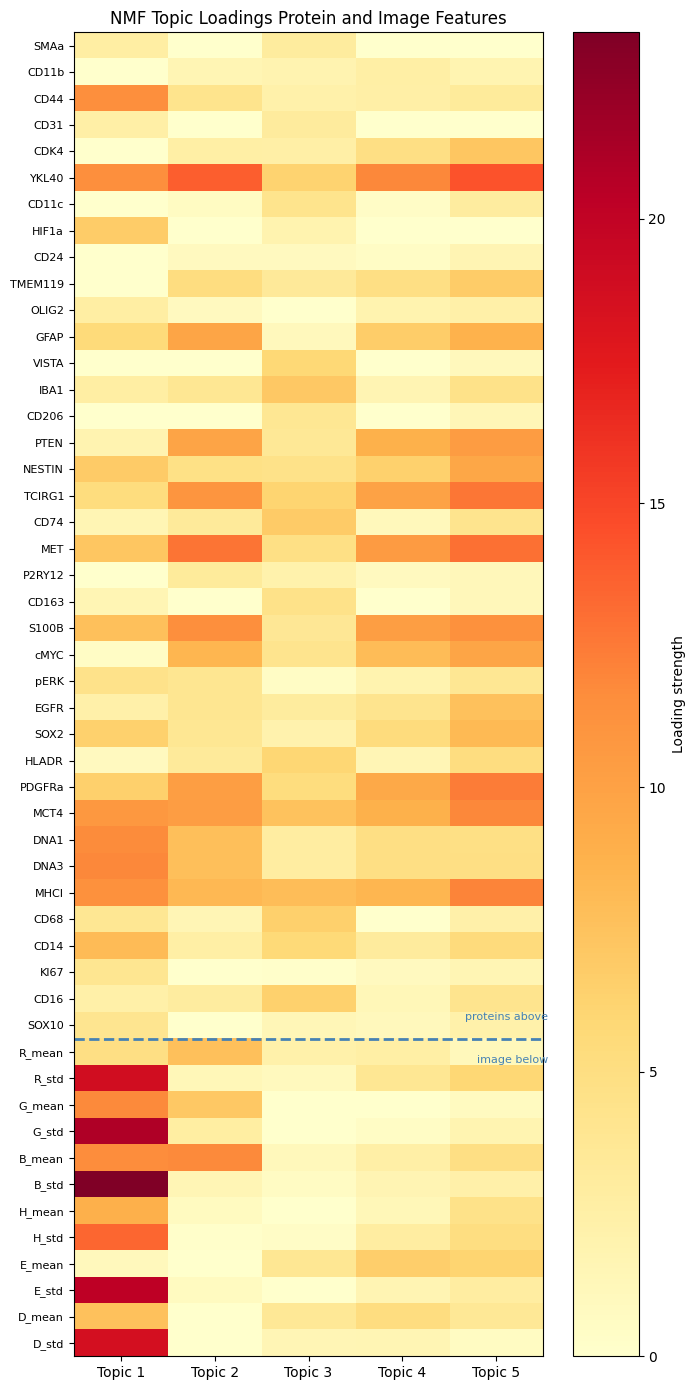

In [25]:
import matplotlib.pyplot as plt

# feature names in the same order as the concatenated matrix
image_feat_names = ['R_mean','R_std','G_mean','G_std','B_mean','B_std',
                    'H_mean','H_std','E_mean','E_std','D_mean','D_std']
all_feat_names = protein_names + image_feat_names
topic_labels = [f'Topic {k+1}' for k in range(K)]

# heatmap of topic loadings: rows = features, columns = topics
fig, ax = plt.subplots(figsize=(7, 14))
im = ax.imshow(H.T, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(K))
ax.set_xticklabels(topic_labels, fontsize=10)
ax.set_yticks(range(len(all_feat_names)))
ax.set_yticklabels(all_feat_names, fontsize=8)

# separator line between protein features and image features
ax.axhline(37.5, color='steelblue', linewidth=2, linestyle='--')
ax.text(K - 0.45, 36.5, 'proteins above', va='top', ha='right', fontsize=8, color='steelblue')
ax.text(K - 0.45, 38.5, 'image below',    va='bottom', ha='right', fontsize=8, color='steelblue')

plt.colorbar(im, ax=ax, label='Loading strength')
ax.set_title('NMF Topic Loadings Protein and Image Features')
plt.tight_layout()
plt.savefig('output/bonus_nmf_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

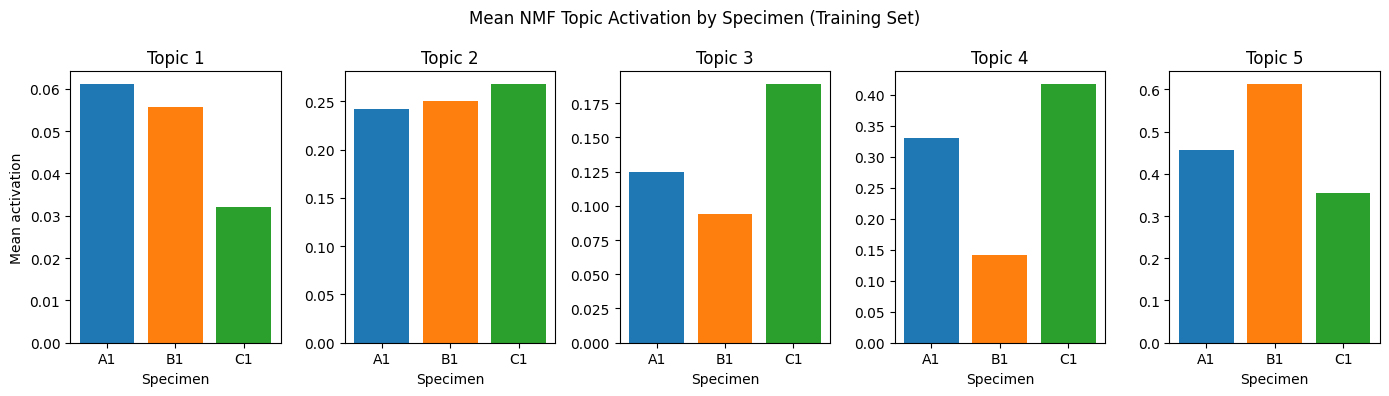

In [26]:
# mean topic activation per specimen for training spots
specimen_train_labels = train_df.loc[train_valid_ids, 'specimen_id'].values
specimens = ['A1', 'B1', 'C1']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, K, figsize=(14, 4), sharey=False)
for k in range(K):
    means = [W[specimen_train_labels == s, k].mean() for s in specimens]
    axes[k].bar(specimens, means, color=colors)
    axes[k].set_title(f'Topic {k+1}')
    axes[k].set_xlabel('Specimen')
    if k == 0:
        axes[k].set_ylabel('Mean activation')

plt.suptitle('Mean NMF Topic Activation by Specimen (Training Set)')
plt.tight_layout()
plt.savefig('output/bonus_nmf_specimen_activation.png', dpi=150, bbox_inches='tight')
plt.show()

**Topic 1** is the only topic that loads strongly on image features, with R_std, G_std, B_std, E_std and D_std all showing the highest loading strengths in the heatmap. It also picks up modest contributions from a few proteins (YKL40, CD44, HIF1a). Intuitively, this topic seems to capture how "spread out" the colours are in a patch, where spots with uneven staining tend to activate it more. Its mean activation is reasonably balanced across A1, B1 and C1 (0.061, 0.053, 0.032), suggesting it is not specific to one specimen. This makes Topic 1 the closest thing the model finds to a shared latent factor that bridges image appearance and protein expression.

**Topic 2** loads broadly across many proteins including YKL40, MET, GFAP, NESTIN, TCIRG1 and PDGFRa, with near-zero image feature loadings. Its specimen activations are the most evenly distributed of the five (A1 0.24, B1 0.25, C1 0.28). A topic that activates at similar levels across all three specimens is less likely to be driven by staining differences between batches and more likely to reflect a genuine pattern in protein co-expression that exists regardless of which sample the spot came from. Topic 2 is therefore the strongest candidate for a biologically meaningful latent factor.

**Topics 3, 4 and 5** are also protein-dominated with minimal image coupling, but their specimen activations are noticeably uneven. Topic 3 is much stronger in C1 (0.185) than in B1 (0.093), Topic 4 shows a low B1 activation (0.14) compared to A1 (0.33) and C1 (0.41), and Topic 5 peaks in B1 (0.60) while being weaker in A1 (0.43) and C1 (0.35). These imbalances suggest that Topics 3 to 5 are picking up protein patterns that are at least partly specific to individual specimens rather than being consistently shared across all of them.

Overall, the NMF decomposition separates image variation from protein variation quite cleanly. Only Topic 1 meaningfully bridges both modalities, while Topics 2 to 5 are almost entirely protein-driven. The even specimen activations in Topics 1 and 2 suggest some latent structure is genuinely shared across specimens, while the imbalances in Topics 3 to 5 show that specimen identity still leaves a footprint on protein variation even after factorisation.

## Question 2: Predicting Protein Expression from Image Features

### (a) Association Between H-channel Intensity and cMYC Expression

For each spot we define:

- **H_i** = mean H-channel intensity of the image patch (already extracted in Q1(a) as column index 6 of `X_img_train_raw`)
- **y_i** = cMYC protein expression value (column `cMYC` of the training protein matrix)

All analysis in this section uses the training set (A1, B1, C1) with raw, unscaled values so that the regression coefficients remain interpretable in their original units.

In [ ]:
import numpy as np

# extract H-channel mean and cMYC expression from training data (raw, unscaled)
cmyc_idx = protein_names.index('cMYC')
H_train = X_img_train_raw[:, 6]        # H-channel mean intensity
y_train = X_prot_train_raw[:, cmyc_idx] # cMYC expression

print(f"H_i   range: [{H_train.min():.4f}, {H_train.max():.4f}]  mean={H_train.mean():.4f}")
print(f"cMYC  range: [{y_train.min():.4f}, {y_train.max():.4f}]  mean={y_train.mean():.4f}")
print(f"N spots: {len(H_train)}")

#### 1. Scatter Plot of H-channel Intensity vs cMYC Expression

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# fit a line to overlay on the scatter plot
m, b = np.polyfit(H_train, y_train, 1)
x_line = np.linspace(H_train.min(), H_train.max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(H_train, y_train, alpha=0.15, s=6, color='steelblue', label='Training spots')
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label='Regression line')
ax.set_xlabel('H-channel Mean Intensity (H_i)')
ax.set_ylabel('cMYC Expression (y_i)')
ax.set_title('H-channel Intensity vs cMYC Expression')
ax.legend()
plt.tight_layout()
plt.savefig('output/q2a_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2. Pearson and Spearman Correlation

In [ ]:
from scipy import stats

pearson_r,  pearson_p  = stats.pearsonr(H_train, y_train)
spearman_r, spearman_p = stats.spearmanr(H_train, y_train)

print(f"Pearson  r = {pearson_r:.4f}   p = {pearson_p:.4e}")
print(f"Spearman r = {spearman_r:.4f}   p = {spearman_p:.4e}")

#### 3. Simple Linear Regression

In [ ]:
import statsmodels.api as sm

# fit y_i ~ beta_0 + beta_1 * H_i
X_ols = sm.add_constant(H_train)
ols_model = sm.OLS(y_train, X_ols).fit()

beta_0 = ols_model.params[0]
beta_1 = ols_model.params[1]
r_squared = ols_model.rsquared
p_beta1 = ols_model.pvalues[1]

print(f"beta_0 (intercept) = {beta_0:.4f}")
print(f"beta_1             = {beta_1:.4f}")
print(f"R²                 = {r_squared:.4f}")
print(f"p-value (beta_1)   = {p_beta1:.4e}")

The p-value for beta_1 is 3.98e-07, which is far below the standard 0.05 threshold, so the association between H-channel intensity and cMYC expression is **statistically significant**. The negative beta_1 of -15.21 indicates that spots with higher H-channel intensity tend to have lower cMYC expression.

However, the R² of 0.0031 shows that H-channel intensity alone explains only 0.31% of the variance in cMYC expression. The association, while statistically real, is extremely weak in practical terms. The Spearman correlation (-0.1751) being notably larger in magnitude than the Pearson correlation (-0.0561) also suggests the relationship is non-linear and sensitive to outliers, so a simple linear model is a poor description of the true relationship.

#### Bonus — Controlling for Specimen ID

To test whether the H-cMYC association reflects a genuine within-specimen relationship rather than a between-specimen batch effect, we add specimen identity as a set of dummy variables to the regression model.

The extended model is:

y_i ~ β₀ + β₁·H_i + β₂·Spec_B1 + β₃·Spec_C1

where Spec_B1 and Spec_C1 are binary indicators for specimens B1 and C1 (A1 is the reference). If β₁ remains similar in magnitude and significance after adding these controls, the H-cMYC association holds within specimens and is not merely a specimen-level artifact. If β₁ drops substantially or becomes non-significant, the association was largely driven by between-specimen differences.

In [ ]:
import pandas as pd
import statsmodels.api as sm

# build a DataFrame with H, cMYC and specimen dummies
specimen_train_arr = train_df.loc[train_valid_ids, 'specimen_id'].values
bonus_df = pd.DataFrame({
    'H':    H_train,
    'cMYC': y_train,
    'Spec_B1': (specimen_train_arr == 'B1').astype(int),
    'Spec_C1': (specimen_train_arr == 'C1').astype(int),
})

X_bonus = sm.add_constant(bonus_df[['H', 'Spec_B1', 'Spec_C1']])
bonus_model = sm.OLS(bonus_df['cMYC'], X_bonus).fit()

print(bonus_model.summary2().tables[1][['Coef.','P>|t|','[0.025','0.975]']])
print(f"
R² with specimen controls: {bonus_model.rsquared:.4f}")
print(f"R² without controls:        {r_squared:.4f}")

After controlling for specimen identity, the coefficient for H remains negative and statistically significant (beta_1 = -12.81, p = 0.000630). The specimen dummy variables are both far from significant (Spec_B1 p = 0.94, Spec_C1 p = 0.25), and the R² increases only marginally from 0.0031 to 0.0033. This means that specimen identity contributes essentially nothing to explaining cMYC expression once H is already in the model.

The conclusion is that the H-cMYC association is **robust to specimen-level differences** and is not merely a batch effect. The relationship holds within each specimen, which makes it a genuine statistical signal rather than an artifact of between-specimen staining variation. That said, the overall explanatory power remains very low regardless of whether specimen controls are included.